# Лабораторная 03. Ключевые точки и выравнивание лица — исследовательские стенды

Маршрут рассчитан примерно на 90–110 минут на CPU. Выполните пять подготовительных ячеек сверху вниз. Затем идите по стендам 1–6. В каждом сначала сделайте прогноз, затем меняйте параметры, фиксируйте числа и объясняйте причинную связь. Кнопки стенда 1 запускают настоящую нейросеть; остальные стенды изолируют геометрию и протокол оценки на воспроизводимых учебных данных. В основной работе вы реализуете эти правила самостоятельно и проверите их на val/test.

| Стенд | Что исследуется | Где требуется решение |
|---|---|---|
| 1 | YuNet: рамка, пять точек, выравнивание, скорость CPU | Размер, перекрытие, поворот, порог |
| 2 | Рамка в crop и обратное преобразование | Политика центра, поле, дрожание, размер |
| 3 | Амодальная разметка, видимость, NME и PCK | Маска оценивания и порог |
| 4 | Карта, несколько декодеров и отказ | Квантование, ложная вершина, неоднозначность |
| 5 | Два глаза, три точки и взвешенное подобие | Истинная ошибка против остатка подгонки |
| 6 | Серия val/test случаев | Выбор веса по средней и хвостовой ошибке |

Снимок астронавта Эйлин Коллинз (NASA, общественное достояние) берётся из scikit-image. Он скачивается во временный кэш с проверкой SHA-256; при отсутствии сети вместо фото можно изучать учебный рисунок. Для офлайн-запуска исходного снимка задайте FACE_LAB_ASTRONAUT_PATH. Веса YuNet также проверяются по SHA-256 и остаются во временном каталоге; для офлайн-запуска сети можно задать FACE_LAB_YUNET_PATH. Если весов нет, только на исходном снимке 512×512 показывается явно подписанный сохранённый вывод без времени выполнения. Ручные пять точек приблизительны. Личные снимки и кэш не добавляйте в Git.

In [1]:
import os, time, hashlib, tempfile, urllib.request
from pathlib import Path
import numpy as np, cv2, matplotlib.pyplot as plt
np.set_printoptions(precision=3, suppress=True)
print("numpy", np.__version__, "OpenCV", cv2.__version__, "CPU")

numpy 2.4.6 OpenCV 5.0.0 CPU


In [2]:
# NASA / Eileen Collins, via scikit-image 0.25.2. Manual points are approximate.
URL = "https://raw.githubusercontent.com/scikit-image/scikit-image/v0.25.2/skimage/data/astronaut.png"
SHA = "88431cd9653ccd539741b555fb0a46b61558b301d4110412b5bc28b5e3ea6cb5"
GT = np.array([[201,101],[248,103],[225,123],[206,144],[247,144]], dtype=float)
TARGET = np.array([[42,49],[86,49],[64,73],[47,97],[81,97]], dtype=float)
NAMES = ["левый глаз на изображении","правый глаз","нос","левый угол рта","правый угол рта"]
def fallback():
    im=np.full((512,512,3),(234,239,245),np.uint8)
    cv2.ellipse(im,(225,125),(78,100),0,0,360,(235,204,181),-1)
    for x,y in GT[:2].astype(int):
        cv2.ellipse(im,(x,y),(12,6),0,0,360,(255,255,255),-1)
        cv2.circle(im,(x,y),4,(42,64,86),-1)
    cv2.circle(im,tuple(GT[2].astype(int)),4,(142,100,90),-1)
    cv2.line(im,tuple(GT[3].astype(int)),tuple(GT[4].astype(int)),(145,70,75),3)
    return im
def load_photo():
    local=os.getenv("FACE_LAB_ASTRONAUT_PATH")
    path=Path(local) if local else Path(tempfile.gettempdir())/"applied_ai_face_lab"/"astronaut.png"
    if not path.exists() and not local:
        try:
            path.parent.mkdir(parents=True,exist_ok=True)
            with urllib.request.urlopen(URL,timeout=20) as r: raw=r.read()
            if hashlib.sha256(raw).hexdigest()!=SHA: raise ValueError("SHA-256 mismatch")
            path.write_bytes(raw)
        except Exception as e:
            print("Снимок недоступен; учебный рисунок:",str(e)[:120])
            return fallback(),False
    raw=path.read_bytes()
    if hashlib.sha256(raw).hexdigest()!=SHA: raise ValueError("SHA-256 mismatch")
    image=cv2.imdecode(np.frombuffer(raw,np.uint8),cv2.IMREAD_COLOR)
    if image is None or image.shape[:2]!=(512,512): raise ValueError("Требуется снимок 512×512")
    return cv2.cvtColor(image,cv2.COLOR_BGR2RGB),True
PHOTO,IS_REAL=load_photo()
print("Источник:", "NASA / Eileen Collins" if IS_REAL else "учебный рисунок")

Источник: NASA / Eileen Collins


In [3]:
def show_points(ax,image,points,title,marker="o",color="orange"):
    ax.imshow(image)
    p=np.asarray(points)
    ax.scatter(p[:,0],p[:,1],s=55,c=color,marker=marker,edgecolors="black")
    for i,(x,y) in enumerate(p): ax.text(x+4,y-3,str(i),color="white",fontsize=9,
        bbox=dict(facecolor="black",alpha=.6,pad=1))
    ax.set_title(title);ax.axis("off")
def eye_transform(src,dst):
    # Similarity determined by two eye centers.
    src=np.asarray(src,float);dst=np.asarray(dst,float)
    u=src[1]-src[0];v=dst[1]-dst[0]
    if np.linalg.norm(u)<1e-8: raise ValueError("Глаза совпали")
    s=np.linalg.norm(v)/np.linalg.norm(u)
    a=np.arctan2(v[1],v[0])-np.arctan2(u[1],u[0])
    R=np.array([[np.cos(a),-np.sin(a)],[np.sin(a),np.cos(a)]])
    A=s*R;t=dst[0]-A@src[0]
    return np.column_stack([A,t])
def move(points,M):
    p=np.asarray(points,float)
    return p@M[:,:2].T+M[:,2]
def crop(image,M):
    return cv2.warpAffine(image,M,(128,128),borderValue=(240,240,240))

In [4]:
import sys, subprocess
from IPython.display import display
from matplotlib.patches import Circle, Rectangle
try:
    import ipywidgets as widgets
except ImportError:
    try:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "ipywidgets>=8.1,<9"])
        import ipywidgets as widgets
    except Exception as exc:
        widgets = None
        print("Виджеты недоступны; статические примеры работают:", str(exc)[:120])
try:
    from google.colab import output as colab_output
    colab_output.enable_custom_widget_manager()
except ImportError:
    pass
CONTROL_PANELS = {}
def stand_controls(name, function, **controls):
    if widgets is None:
        return None
    for control in controls.values():
        if hasattr(control, "continuous_update"):
            control.continuous_update = False
        control.style = {"description_width": "155px"}
        control.layout = widgets.Layout(width="470px")
    output = widgets.interactive_output(function, controls)
    display(widgets.VBox(list(controls.values()) + [output]))
    CONTROL_PANELS[name] = controls
    return controls
def finish(fig):
    fig.tight_layout()
    plt.show()
    plt.close(fig)

In [5]:
POINT_LABELS = ["0 · левый глаз на снимке", "1 · правый глаз",
                "2 · нос", "3 · левый угол рта", "4 · правый угол рта"]

## Стенд 1. Реальная модель: YuNet, перекрытие и цена разрешения

**Что здесь настоящее.** YuNet (OpenCV Zoo) вычисляет рамку, пять точек и confidence на снимке NASA. Модель загружается только после нажатия кнопки, проверяется по SHA-256 и хранится во временном каталоге. В репозиторий веса и фотография не попадают. При отсутствии сети, **если исходный снимок уже доступен локально**, работает сохранённый результат именно для него при 512×512; у этого результата нет измеренного на вашем компьютере времени, и он не применяется к повёрнутым или закрытым лицам. Источник модели: [OpenCV Zoo, YuNet](https://github.com/opencv/opencv_zoo/tree/47534e2/models/face_detection_yunet), [веса](https://github.com/opencv/opencv_zoo/blob/47534e2/models/face_detection_yunet/face_detection_yunet_2026may.onnx), [лицензия MIT](https://github.com/opencv/opencv_zoo/blob/47534e2/models/face_detection_yunet/LICENSE).

**Схема выхода.** Столбцы детектора: `(x, y, width, height)`, затем пять пар координат (левый на изображении глаз, правый глаз, нос, левый и правый на изображении углы рта), затем score. После изменения размера входа все координаты переводятся обратно в исходные 512×512. Красные кресты — YuNet, оранжевые точки — приблизительная ручная разметка. NME относительно неё показывает расхождение **на этом учебном снимке**, а не качество модели на датасете. Выравнивание строится по двум предсказанным глазам и лишь подготавливает crop; идентификации здесь нет.

**Что измеряем.** Время — медиана пяти вызовов `detect` на CPU после прогрева, без загрузки модели, скачивания, ресайза, рисования и вывода. Повторное обращение к тому же сценарию и размеру использует сохранённые в памяти предсказания; тогда новых измерений нет. В таблице раздельно показаны score, число кандидатов, NME и время исходного вычисления. Изменение порога score фильтрует сохранённые кандидаты и не запускает сеть заново.

**Прогноз.** Поворот или закрытие точки может изменить и рамку, и все пять оценок. Более высокий порог способен убрать ложную рамку, но также может убрать лицо целиком. Большее разрешение обычно требует больше вычислений; точность на одном кадре не обязана меняться монотонно.

In [6]:
YUNET_URL = "https://media.githubusercontent.com/media/opencv/opencv_zoo/47534e2/models/face_detection_yunet/face_detection_yunet_2026may.onnx"
YUNET_SHA = "ebafce4e3c118d6554634be5c27ab333b4c047a9a8c3faf1d7cf93101c22f0f0"
YUNET_BYTES = 229738
YUNET_CACHE_PATH = Path(tempfile.gettempdir()) / "applied_ai_face_lab" / "face_detection_yunet_2026may.onnx"
YUNET_RAW_CACHE = {}
YUNET_HISTORY = []
YUNET_DOWNLOAD_FAILED = False
YUNET_LAST_STATE = None
# Замороженный вывод YuNet 2026may, OpenCV 5.0.0 CPU, исходный NASA-снимок 512×512.
# Это запасной демонстрационный результат, а не измерение вашей среды.
YUNET_FROZEN_512 = np.array([[178.16728, 62.90826, 89.89951, 113.33239,
    200.11598, 101.81963, 247.13364, 102.61931, 220.36716, 124.54450,
    198.61287, 142.77434, 239.66765, 143.63808, 0.93232733]], dtype=np.float32)
YUNET_SCENARIOS = {
    "original": "Исходный снимок",
    "roll_plus": "Поворот +25°",
    "roll_minus": "Поворот −25°",
    "eye_cover": "Закрыт левый на снимке глаз",
    "nose_cover": "Закрыт нос",
    "double_cover": "Закрыты глаз и нос",
}

def yunet_image(scenario="original"):
    if scenario not in YUNET_SCENARIOS:
        raise ValueError("Неизвестный сценарий")
    image = PHOTO.copy()
    manual = GT.copy()
    hidden = np.zeros(5, dtype=bool)
    if scenario in ("roll_plus", "roll_minus"):
        angle = 25 if scenario == "roll_plus" else -25
        R = cv2.getRotationMatrix2D((225, 115), angle, 1.)
        image = cv2.warpAffine(image, R, (512, 512), borderValue=(240, 240, 240))
        manual = move(manual, R)
    if scenario in ("eye_cover", "double_cover"):
        cv2.rectangle(image, (181, 87), (222, 117), (85, 85, 85), -1)
        hidden[0] = True
    if scenario in ("nose_cover", "double_cover"):
        cv2.rectangle(image, (205, 109), (244, 138), (85, 85, 85), -1)
        hidden[2] = True
    return image, manual, hidden

def yunet_model_path():
    global YUNET_DOWNLOAD_FAILED
    chosen = os.getenv("FACE_LAB_YUNET_PATH")
    path = Path(chosen) if chosen else YUNET_CACHE_PATH
    if path.exists():
        digest = hashlib.sha256(path.read_bytes()).hexdigest()
        if digest == YUNET_SHA:
            return path
        if chosen:
            raise ValueError("FACE_LAB_YUNET_PATH: SHA-256 не совпал с официальной моделью")
        path.unlink()
    if chosen:
        raise FileNotFoundError("Указанный FACE_LAB_YUNET_PATH не найден")
    if YUNET_DOWNLOAD_FAILED:
        return None
    try:
        path.parent.mkdir(parents=True, exist_ok=True)
        with urllib.request.urlopen(YUNET_URL, timeout=12) as response:
            raw = response.read(YUNET_BYTES + 1)
        if len(raw) != YUNET_BYTES or hashlib.sha256(raw).hexdigest() != YUNET_SHA:
            raise ValueError("Размер или SHA-256 ONNX не совпал")
        part = path.with_suffix(".part")
        part.write_bytes(raw)
        os.replace(part, path)
        return path
    except Exception as exc:
        YUNET_DOWNLOAD_FAILED = True
        print("YuNet не загружен; доступен только сохранённый базовый результат:", str(exc)[:160])
        return None

def yunet_raw(scenario="original", input_size=512):
    n = int(input_size)
    if n not in (320, 512, 768):
        raise ValueError("Размер должен быть 320, 512 или 768")
    if not IS_REAL:
        return None, False, "Для реального стенда нужен исходный снимок NASA"
    key = (scenario, n, YUNET_SHA, cv2.__version__)
    if key in YUNET_RAW_CACHE:
        return YUNET_RAW_CACHE[key], True, None
    path = yunet_model_path()
    if path is None:
        if scenario == "original" and n == 512:
            item = {"faces": YUNET_FROZEN_512.copy(), "source": "сохранённый вывод",
                    "median_ms": None, "runs": 0}
            return item, False, None
        return None, False, "Без ONNX-модели этот сценарий недоступен; сохранённый вывод относится только к исходному 512×512"
    image, _, _ = yunet_image(scenario)
    bgr = cv2.cvtColor(image, cv2.COLOR_RGB2BGR)
    small = cv2.resize(bgr, (n, n), interpolation=cv2.INTER_AREA if n < 512 else cv2.INTER_CUBIC)
    try:
        detector = cv2.FaceDetectorYN.create(str(path), "", (n, n), 0.05, 0.3, 100)
        detector.detect(small)  # прогрев, не включён во время
        durations = []
        faces = None
        for _ in range(5):
            started = time.perf_counter()
            _, faces = detector.detect(small)
            durations.append(1000 * (time.perf_counter() - started))
    except cv2.error as exc:
        return None, False, "OpenCV не смог запустить YuNet: " + str(exc).splitlines()[0]
    faces = np.empty((0, 15), np.float32) if faces is None else faces.copy()
    if len(faces):
        faces[:, :14] *= 512. / n
        faces = faces[np.argsort(faces[:, 14])[::-1]]
    item = {"faces": faces, "source": "YuNet / CPU", "median_ms": float(np.median(durations)),
            "runs": len(durations)}
    YUNET_RAW_CACHE[key] = item
    return item, False, None

def yunet_state(scenario="original", input_size=512, score_threshold=.8):
    if scenario not in YUNET_SCENARIOS:
        raise ValueError("Неизвестный сценарий")
    threshold = float(score_threshold)
    if not 0.05 <= threshold <= .99:
        raise ValueError("Порог score должен быть от 0.05 до 0.99")
    image, manual, hidden = yunet_image(scenario)
    raw, cache_hit, problem = yunet_raw(scenario, input_size)
    state = {"scenario": scenario, "input_size": int(input_size), "threshold": threshold,
             "image": image, "manual": manual, "hidden": hidden, "cache_hit": cache_hit,
             "problem": problem, "source": None, "median_ms": None,
             "all_count": 0, "kept_count": 0, "selected": None,
             "nme": None, "mean_error_px": None, "aligned_error_px": None}
    if raw is None:
        return state
    state["source"] = raw["source"]
    state["median_ms"] = raw["median_ms"]
    state["all_count"] = len(raw["faces"])
    state["all_faces"] = raw["faces"]
    kept = raw["faces"][raw["faces"][:, 14] >= threshold]
    state["kept"] = kept
    state["kept_count"] = len(kept)
    if len(kept):
        face = kept[0]
        landmarks = face[4:14].reshape(5, 2).astype(float)
        discrepancy = np.linalg.norm(landmarks - manual, axis=1)
        M = eye_transform(landmarks[:2], TARGET[:2])
        manual_after = move(manual, M)
        state.update(selected=face, landmarks=landmarks, discrepancy=discrepancy, M=M,
            manual_after=manual_after, mean_error_px=float(discrepancy.mean()),
            nme=float(discrepancy.mean() / np.linalg.norm(manual[1] - manual[0])),
            aligned_error_px=float(np.linalg.norm(manual_after - TARGET, axis=1).mean()))
    return state

def render_yunet_state(state):
    image = state["image"]
    manual = state["manual"]
    selected = state["selected"]
    fig, ax = plt.subplots(2, 2, figsize=(12, 8))
    ax[0, 0].imshow(image)
    ax[0, 0].set(title="Кадр и рамки выше порога")
    for k, face in enumerate(state.get("kept", [])):
        x, y, w, h = map(float, face[:4])
        ax[0, 0].add_patch(Rectangle((x, y), w, h, fill=False,
            edgecolor="crimson" if k == 0 else "gold", linewidth=2.7 if k == 0 else 1.5))
        ax[0, 0].text(x, max(10, y - 3), f"{float(face[14]):.2f}", color="white", fontsize=9,
                      bbox=dict(facecolor="crimson" if k == 0 else "#444", pad=2))
    ax[0, 0].axis("off")
    ax[0, 1].imshow(image)
    ax[0, 1].scatter(manual[:, 0], manual[:, 1], c="orange", s=62, edgecolors="black", label="ручная")
    if selected is not None:
        p = state["landmarks"]
        ax[0, 1].scatter(p[:, 0], p[:, 1], c="crimson", marker="x", s=100,
                          linewidths=2, label="YuNet")
        for i in range(5):
            ax[0, 1].plot([manual[i, 0], p[i, 0]], [manual[i, 1], p[i, 1]],
                          color="deepskyblue", linewidth=1.3)
    cx, cy = np.mean(manual, axis=0)
    ax[0, 1].set(xlim=(cx - 85, cx + 85), ylim=(cy + 90, cy - 90),
                 title="Пять точек: модель и разметка")
    ax[0, 1].legend(loc="lower right", fontsize=8)
    if selected is not None:
        aligned = crop(image, state["M"])
        ax[1, 0].imshow(aligned)
        ax[1, 0].scatter(TARGET[:, 0], TARGET[:, 1], s=90, facecolors="none",
                         edgecolors="cyan", linewidths=2, label="шаблон")
        ax[1, 0].scatter(state["manual_after"][:, 0], state["manual_after"][:, 1],
                         c="orange", s=45, edgecolors="black", label="ручная после warp")
        ax[1, 0].legend(loc="lower right", fontsize=8)
        colors = ["#9c9c9c" if h else "#4178a8" for h in state["hidden"]]
        ax[1, 1].bar(np.arange(5), state["discrepancy"], color=colors)
        ax[1, 1].set(xticks=np.arange(5), xlabel="Номер точки",
                     ylabel="Расхождение с ручной разметкой, px",
                     title=f"NME ≈ {100*state['nme']:.1f}% · score {float(selected[14]):.3f}")
    else:
        ax[1, 0].text(.5, .5, "Нет лица выше порога; crop не строится",
                      ha="center", va="center", transform=ax[1, 0].transAxes)
        scores = state["all_faces"][:, 14]
        if len(scores):
            ax[1, 1].bar(np.arange(1, len(scores) + 1), scores, color="steelblue")
            ax[1, 1].axhline(state["threshold"], color="crimson", linestyle="--",
                             label=f"Ваш порог {state['threshold']:.2f}")
            ax[1, 1].set(xlabel="Кандидат после NMS, ранг по score",
                         ylabel="Score", ylim=(0, 1),
                         xticks=np.arange(1, len(scores) + 1),
                         title="Почему рамка исчезла")
            ax[1, 1].legend(fontsize=8)
        else:
            ax[1, 1].text(.5, .5, "YuNet не выдал кандидатов",
                          ha="center", va="center", transform=ax[1, 1].transAxes)
            ax[1, 1].axis("off")
    ax[1, 0].set(title="Выравнивание по предсказанным глазам")
    ax[1, 0].axis("off")
    fig.suptitle(YUNET_SCENARIOS[state["scenario"]] + f" · вход {state['input_size']}×{state['input_size']}")
    fig.tight_layout(rect=(0, 0, 1, .96))
    plt.show()
    plt.close(fig)

def yunet_history_table():
    print("Журнал опытов (последние 12):")
    print(f"{'Сценарий':<25} {'Вход':>5} {'Порог':>6} {'Лиц':>5} {'Score':>7} {'NME%':>7} {'CPU ms':>9}  Источник")
    for row in YUNET_HISTORY[-12:]:
        score = "—" if row["selected"] is None else f"{float(row['selected'][14]):.3f}"
        nme = "—" if row["nme"] is None else f"{100*row['nme']:.1f}"
        ms = "—" if row["median_ms"] is None else f"{row['median_ms']:.1f}"
        origin = (row["source"] or "недоступно") + ("; кэш" if row["cache_hit"] else "")
        print(f"{YUNET_SCENARIOS[row['scenario']]:<25} {row['input_size']:>5} {row['threshold']:>6.2f} "
              f"{row['kept_count']:>5} {score:>7} {nme:>7} {ms:>9}  {origin}")

def run_yunet(scenario="original", input_size=512, score_threshold=.8, show=True):
    global YUNET_LAST_STATE
    state = yunet_state(scenario, input_size, score_threshold)
    YUNET_LAST_STATE = state
    YUNET_HISTORY.append(state)
    if state["problem"]:
        print(state["problem"])
    else:
        if show:
            render_yunet_state(state)
        print("Кандидатов после NMS при score≥0.05:", state["all_count"],
              "; после вашего порога:", state["kept_count"])
        if state["selected"] is not None:
            f = state["selected"]
            print("Главная рамка (x,y,w,h):", np.round(f[:4], 1),
                  "; score:", round(float(f[14]), 3))
            print("Расхождение с приблизительной разметкой: среднее",
                  round(state["mean_error_px"], 2), "px; NME",
                  round(100*state["nme"], 2), "%")
            print("После выравнивания: среднее расстояние ручных точек до шаблона",
                  round(state["aligned_error_px"], 2), "px")
        if state["median_ms"] is None:
            print("Сохранённый вывод: время CPU для этой среды не измерялось")
        else:
            print("CPU detect: медиана 5 запусков после прогрева =",
                  round(state["median_ms"], 2), "мс; OpenCV", cv2.__version__,
                  "; потоков", cv2.getNumThreads(),
                  "; предсказания из памяти:" , state["cache_hit"])
    yunet_history_table()
    return state

def run_yunet_sweep(scenario="original", score_threshold=.8):
    states = [run_yunet(scenario, n, score_threshold, show=False) for n in (320, 512, 768)]
    comparable = [s for s in states if s["median_ms"] is not None and s["nme"] is not None]
    if comparable:
        fig, ax = plt.subplots(1, 2, figsize=(10, 3.6))
        ax[0].plot([s["input_size"] for s in comparable],
                   [s["median_ms"] for s in comparable], "o-", color="darkorange")
        ax[0].set(xlabel="Размер входа, px", ylabel="CPU detect, мс", title="Цена разрешения")
        ax[1].plot([s["input_size"] for s in comparable],
                   [100*s["nme"] for s in comparable], "o-", color="steelblue")
        ax[1].set(xlabel="Размер входа, px", ylabel="NME, %", title="Расхождение с ручной разметкой")
        for a in ax:
            a.grid(alpha=.25)
        finish(fig)
    return states

In [7]:
from IPython.display import clear_output
if widgets is not None:
    yunet_scenario_control = widgets.Dropdown(
        options=[(label, key) for key, label in YUNET_SCENARIOS.items()],
        value="original", description="Сценарий", style={"description_width": "110px"},
        layout=widgets.Layout(width="380px"))
    yunet_size_control = widgets.SelectionSlider(
        options=[320, 512, 768], value=512, description="Вход, px",
        continuous_update=False, style={"description_width": "110px"},
        layout=widgets.Layout(width="380px"))
    yunet_threshold_control = widgets.FloatSlider(
        min=.05, max=.99, step=.01, value=.8, description="Score ≥",
        continuous_update=False, readout_format=".2f", style={"description_width": "110px"},
        layout=widgets.Layout(width="380px"))
    yunet_run_button = widgets.Button(description="Запустить YuNet", button_style="primary")
    yunet_sweep_button = widgets.Button(description="Сравнить 3 размера")
    yunet_clear_button = widgets.Button(description="Очистить журнал")
    yunet_output = widgets.Output()
    def _yunet_click(button):
        button.disabled = True
        try:
            with yunet_output:
                clear_output(wait=True)
                if button is yunet_sweep_button:
                    run_yunet_sweep(yunet_scenario_control.value, yunet_threshold_control.value)
                else:
                    run_yunet(yunet_scenario_control.value, yunet_size_control.value,
                              yunet_threshold_control.value)
        finally:
            button.disabled = False
    def _yunet_clear(_):
        YUNET_HISTORY.clear()
        with yunet_output:
            clear_output(wait=True)
            print("Журнал очищен. Кэш предсказаний оставлен для быстрых повторов.")
    yunet_run_button.on_click(_yunet_click)
    yunet_sweep_button.on_click(_yunet_click)
    yunet_clear_button.on_click(_yunet_clear)
    display(widgets.VBox([
        yunet_scenario_control, yunet_size_control, yunet_threshold_control,
        widgets.HBox([yunet_run_button, yunet_sweep_button, yunet_clear_button]), yunet_output]))
    CONTROL_PANELS["yunet"] = {"scenario": yunet_scenario_control,
        "input_size": yunet_size_control, "score_threshold": yunet_threshold_control,
        "run": yunet_run_button, "sweep": yunet_sweep_button, "clear": yunet_clear_button}
else:
    print("Нет ipywidgets: вызовите run_yunet('original', 512, .8) вручную.")

**Опыты и запись результата.** Нажимайте кнопку после изменения параметров: бегунки здесь только задают конфигурацию. При повторе той же пары «сценарий + размер» сеть не запускается: порог применится к сохранённым кандидатам.

1. Для исходного снимка нажмите **«Сравнить 3 размера»** при пороге 0.8. Запишите для каждого размера число рамок, score, NME и медианное время. Объясните, почему три точки на кривой не являются benchmark на датасете.
2. Для 512×512 сравните исходный снимок, поворот +25° и −25°. Найдите, меняется ли расхождение по всем пяти точкам одинаково. Сравните полученные выровненные crop.
3. Для 512×512 сравните закрытый глаз и закрытый нос с исходным снимком. Отдельно запишите ошибку соответствующей точки и среднюю ошибку остальных четырёх. Скрытая точка всё равно имеет оценку.
4. Для исходного снимка при 512×512 поднимите порог score от 0.8 до 0.94 и затем опустите до 0.05. Когда исчезает лицо? Появляются ли дополнительные кандидаты? Нужен ли повторный запуск сети при смене порога?
5. Повторите одну конфигурацию дважды. По журналу укажите, чем отличается повтор от нового запуска модели и почему его время не следует выдавать за новую скорость вывода.

| Опыт | Score / рамки | Ошибка глаз / носа, px | NME, % | CPU detect, мс | Вывод |
|---|---|---|---:|---:|---|
| Исходный 320/512/768 | | | | | |
| Поворот +25° / −25° | | | | | |
| Закрыт глаз / нос | | | | | |
| Порог 0.8 / 0.94 / 0.05 | | | | | |
| Повтор той же конфигурации | | | | | |

Это сравнение чувствительности **одной модели на одном открытом снимке**. В основной работе гипотезы проверяются на фиксированных val/test сценариях, а не подбираются по внешнему виду одного crop.

## Стенд 2. Цена рамки: coverage, масштаб и обратное отображение

**Механизм.** Возьмём реальную рамку YuNet на исходном кадре: (x=178.17, y=62.91, w=89.90, h=113.33). Три политики строят квадрат: центр рамки модели, центр пяти предсказанных точек или **оракульный учебный центр ручной разметки**. Последний недоступен при реальном выводе без разметки; он служит контрольной границей для сравнения. Затем задаются поле, дрожание центра и размер выходного изображения Q. Матрица переводит исходные пиксели в crop, обратная матрица должна восстановить все пять точек. Цена выбора — число **ручных GT-точек** с запасом не менее 10 px до границы, эффективная ширина лица в crop и Q² выходных пикселей. GT-coverage — офлайн-диагностика; политику и поле для реальной системы выбирают по val. Q² здесь только прокси объёма данных, а не измеренное время сети. Почти нулевая ошибка M⁻¹(M(point)) проверяет лишь алгебру матриц: она не доказывает, что лицо целиком осталось в crop, и не оценивает точность YuNet.

**Цель.** Найдите самый тесный crop, в котором все пять ручных ориентиров остаются внутри с запасом 10 px; затем проверьте, сохраняется ли решение при дрожании рамки.

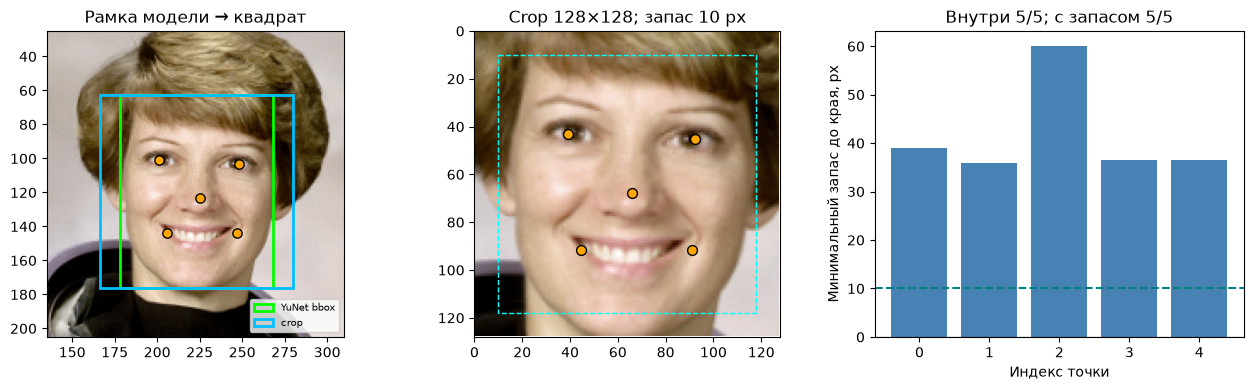

Сторона исходного квадрата 113.3 px; лицо в crop ≈ 101.5 px; площадь bbox / квадрата ≈ 79.3 %
Выходных пикселей 16384 (прокси данных); max ошибка обратного переноса 1.42e-14 px


{'M': array([[   1.129,    0.   , -187.993],
        [   0.   ,    1.129,  -71.05 ]]),
 'H': array([[   1.129,    0.   , -187.993],
        [   0.   ,    1.129,  -71.05 ],
        [   0.   ,    0.   ,    1.   ]]),
 'mapped': array([[39.021, 43.022],
        [92.103, 45.28 ],
        [66.127, 67.869],
        [44.668, 91.587],
        [90.974, 91.587]]),
 'borders': array([39.021, 35.897, 60.131, 36.413, 36.413]),
 'inside': 5,
 'robust': 5,
 'roundtrip': 1.4210854715202004e-14,
 'side': 113.33239,
 'q': 128,
 'center': array([223.117, 119.574]),
 'face_width': 101.53440935993673,
 'occupancy': 0.7932375731245057}

In [8]:
ADV_ROI_BOX = np.array([178.16728, 62.90826, 89.89951, 113.33239])
ADV_ROI_POINTS = np.array([[200.11598,101.81963],[247.13364,102.61931],
                           [220.36716,124.54450],[198.61287,142.77434],
                           [239.66765,143.63808]])
def advanced_roi_state(policy="bbox", margin=1., jitter_x=0., jitter_y=0., size=128):
    x, y, w, h = ADV_ROI_BOX
    if policy == "bbox":
        center = np.array([x+w/2, y+h/2])
    elif policy == "landmarks":
        center = ADV_ROI_POINTS.mean(axis=0)
    elif policy == "manual":
        center = GT.mean(axis=0)
    else:
        raise ValueError("Неизвестная политика crop")
    center = center + [float(jitter_x),float(jitter_y)]
    side = float(max(w,h)*margin)
    q = int(size)
    x0,y0 = center-side/2
    scale=q/side
    M=np.array([[scale,0.,-scale*x0],[0.,scale,-scale*y0]])
    H=np.eye(3);H[:2,:]=M
    mapped=move(GT,M)
    reverse=np.linalg.inv(H)
    restored=np.column_stack([mapped,np.ones(len(mapped))])@reverse.T
    roundtrip=float(np.max(np.linalg.norm(restored[:,:2]-GT,axis=1)))
    borders=np.min(np.column_stack([mapped[:,0],mapped[:,1],
                                    q-mapped[:,0],q-mapped[:,1]]),axis=1)
    robust=int(np.sum(borders>=10.))
    inside=int(np.sum(borders>=0.))
    face_width=float(w/side*q)
    occupancy=float(w*h/side**2)
    return {"M":M,"H":H,"mapped":mapped,"borders":borders,"inside":inside,
            "robust":robust,"roundtrip":roundtrip,"side":side,"q":q,
            "center":center,"face_width":face_width,"occupancy":occupancy}
def render_advanced_roi(policy="bbox",margin=1.,jitter_x=0.,jitter_y=0.,size=128):
    state=advanced_roi_state(policy,margin,jitter_x,jitter_y,size)
    q=state["q"]; side=state["side"]; center=state["center"]
    out=cv2.warpAffine(PHOTO,state["M"],(q,q),borderValue=(240,240,240))
    fig,ax=plt.subplots(1,3,figsize=(13,4))
    ax[0].imshow(PHOTO)
    ax[0].add_patch(Rectangle(ADV_ROI_BOX[:2],ADV_ROI_BOX[2],ADV_ROI_BOX[3],
                              fill=False,edgecolor="lime",linewidth=2,label="YuNet bbox"))
    ax[0].add_patch(Rectangle(center-side/2,side,side,fill=False,
                              edgecolor="deepskyblue",linewidth=2,label="crop"))
    ax[0].scatter(GT[:,0],GT[:,1],c="orange",s=45,edgecolors="black")
    ax[0].set(xlim=(135,310),ylim=(205,25),title="Рамка модели → квадрат")
    ax[0].legend(loc="lower right",fontsize=7)
    ax[1].imshow(out)
    ax[1].scatter(state["mapped"][:,0],state["mapped"][:,1],
                  c="orange",s=50,edgecolors="black")
    ax[1].add_patch(Rectangle((10,10),q-20,q-20,fill=False,
                              edgecolor="cyan",linestyle="--"))
    ax[1].set(xlim=(0,q),ylim=(q,0),title=f"Crop {q}×{q}; запас 10 px")
    colors=["steelblue" if b>=10 else ("darkorange" if b>=0 else "crimson")
            for b in state["borders"]]
    ax[2].bar(np.arange(5),state["borders"],color=colors)
    ax[2].axhline(10,color="teal",linestyle="--")
    ax[2].axhline(0,color="black",linewidth=.8)
    ax[2].set(xticks=np.arange(5),xlabel="Индекс точки",
              ylabel="Минимальный запас до края, px",
              title=f"Внутри {state['inside']}/5; с запасом {state['robust']}/5")
    finish(fig)
    print("Сторона исходного квадрата",round(side,1),"px; лицо в crop ≈",
          round(state["face_width"],1),"px; площадь bbox / квадрата ≈",
          round(100*state["occupancy"],1),"%")
    print("Выходных пикселей",q*q,
          "(прокси данных); max ошибка обратного переноса",
          f"{state['roundtrip']:.2e} px")
    return state
render_advanced_roi()

In [9]:
if widgets is not None:
    stand_controls("roi_advanced",render_advanced_roi,
        policy=widgets.Dropdown(options=[("Центр рамки модели","bbox"),
                                          ("Среднее 5 оценок","landmarks"),
                                          ("Ручной центр, контроль","manual")],
                                value="bbox",description="Политика"),
        margin=widgets.FloatSlider(value=1.,min=.5,max=1.6,step=.05,
                                   description="Поле ×",readout_format=".2f"),
        jitter_x=widgets.IntSlider(value=0,min=-35,max=35,step=5,
                                   description="Дрожание x, px"),
        jitter_y=widgets.IntSlider(value=0,min=-35,max=35,step=5,
                                   description="Дрожание y, px"),
        size=widgets.SelectionSlider(options=[64,128,256],value=128,
                                     description="Размер Q"))

**Задания с поиском решения.**

1. Для политики «Центр рамки модели» найдите минимальное поле из доступных значений, при котором все 5 точек имеют запас не меньше 10 px. Запишите сторону квадрата и эффективную ширину лица.
2. При найденном поле введите дрожание x=+20 px. Какие точки первыми теряют запас? Увеличьте поле лишь настолько, чтобы вернуть 5/5.
3. Сравните три политики при одинаковых Q=128 и поле 1.0. Укажите, где различается coverage, хотя исходные точки не изменились.
4. Удвойте Q до 256 без изменения рамки. Проверьте, что пиксельные координаты и минимальный запас удвоились, а нормированные координаты и roundtrip остались прежними.
5. Запишите цену Q=256 по числу выходных пикселей относительно Q=128; не называйте это ускорением или замедлением модели без её измерения.

| Политика / Q / дрожание | Прогноз 5/5 с запасом? | Факт и min border, px | Ширина лица, px | Q² |
|---|---|---|---|---|
| Минимальное поле |  |  |  |  |
| То же +20 px |  |  |  |  |
| Исправленное поле |  |  |  |  |
| Q=256 |  |  |  |  |

**Связь с конвейером:** неверная рамка может обрезать ориентир ещё до выравнивания; обратное отображение отделяет ошибку системы координат от ошибки модели.

## Стенд 3. Амодальная точка, перекрытие и протокол оценки

**Цель.** Разделить три объекта, которые легко спутать: амодальная разметка задаёт положение точки даже под перекрытием; видимость описывает изображение; маска оценки определяет, какие ошибки входят в метрику. Серый диск закрывает фрагмент фотографии, но не стирает сохранённую координату GT. Две системы A и B здесь — **фиксированные учебные предсказания, не выходы нейросети**. У A нос точен, а четыре другие точки ошибаются на 5 px; у B четыре точки ошибаются на 1 px, а нос — на 22 px. Перекрытие не пересчитывает предсказания: опыт изолирует действие протокола оценки.

Для обеих систем используем одинаковое расстояние между **истинными** глазами d. NME — средняя ошибка включённых точек, делённая на d (меньше лучше). PCK@τ — доля включённых точек с ошибкой не больше τ·d (больше лучше). Порог PCK показан пунктиром на диаграмме. Политика «все 5» может оценивать амодальную закрытую точку; политика «только видимые» её исключает. Физическая видимость, показ амодальной метки и маска оценщика управляются отдельно.

**Перед первым запуском** предскажите, какая система выиграет по NME и по PCK@0.10 при закрытом носе и оценке всех пяти точек. Затем объясните результат через пять отдельных ошибок, а не через внешний вид кропа.

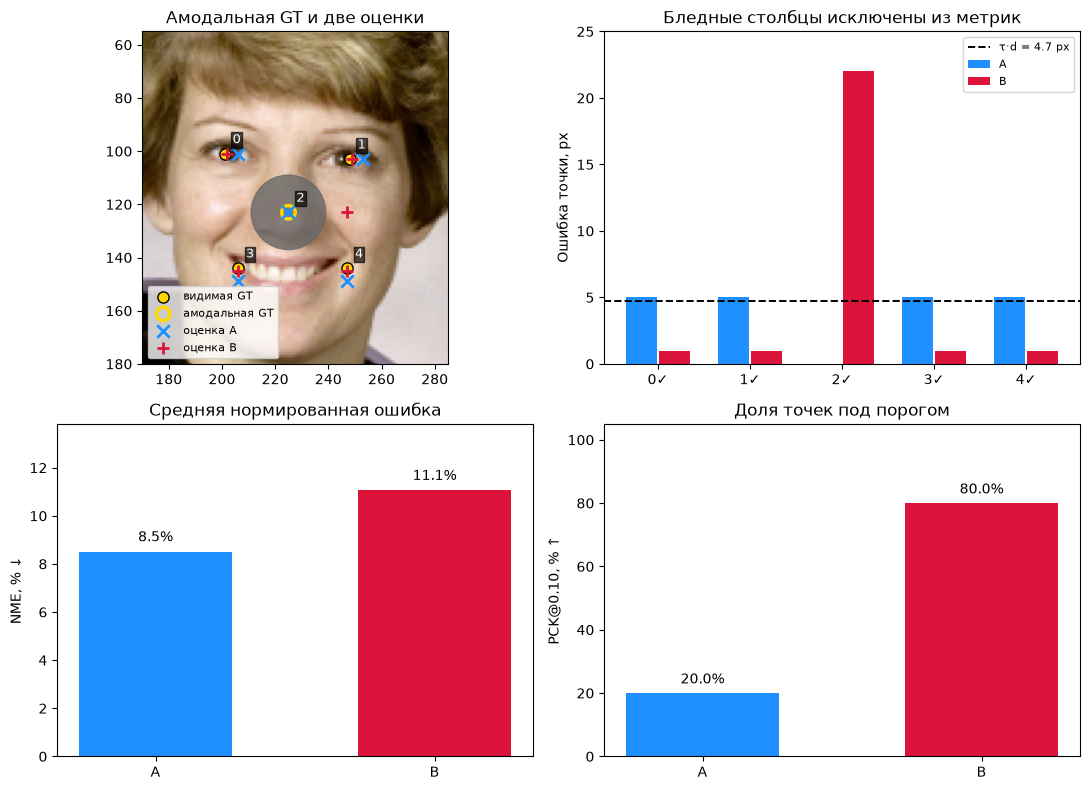

Амодальные GT сохранены для всех 5 точек; физически видимы: [0, 1, 3, 4]
В маске оценщика: [0, 1, 2, 3, 4] ; d=47.04 px; PCK-порог=4.70 px
Ошибки A: [5.0, 5.0, 0.0, 5.0, 5.0] ; B: [1.0, 1.0, 22.0, 1.0, 1.0]
NME A=8.50%, B=11.05%; PCK A=20%, B=80%


{'gt_amodal': array([[201., 101.],
        [248., 103.],
        [225., 123.],
        [206., 144.],
        [247., 144.]]),
 'pred_a': array([[206., 101.],
        [253., 103.],
        [225., 123.],
        [206., 149.],
        [247., 149.]]),
 'pred_b': array([[202., 101.],
        [249., 103.],
        [247., 123.],
        [206., 145.],
        [247., 145.]]),
 'visible': array([ True,  True, False,  True,  True]),
 'mask': array([ True,  True,  True,  True,  True]),
 'hidden': 2,
 'policy': 'all',
 'show_amodal': True,
 'd': 47.042533945356304,
 'cutoff': 4.70425339453563,
 'tau': 0.1,
 'errors_a': array([5., 5., 0., 5., 5.]),
 'errors_b': array([ 1.,  1., 22.,  1.,  1.]),
 'nme_a': 0.08502943324962729,
 'nme_b': 0.11053826322451549,
 'pck_a': 0.2,
 'pck_b': 0.8}

In [10]:
ANNOTATION_A = GT + np.array([[5,0],[5,0],[0,0],[0,5],[0,5]], dtype=float)
ANNOTATION_B = GT + np.array([[1,0],[1,0],[22,0],[0,1],[0,1]], dtype=float)

def annotation_metric_state(hidden=2, policy="all", pck_tau=.10, show_amodal=True):
    hidden = int(hidden)
    if hidden < -1 or hidden >= len(GT):
        raise ValueError("hidden должен быть -1 или индексом точки")
    tau = float(pck_tau)
    if tau < 0 or not np.isfinite(tau):
        raise ValueError("Порог PCK должен быть конечным и неотрицательным")
    visible = np.ones(len(GT), dtype=bool)
    if hidden >= 0:
        visible[hidden] = False
    if policy == "all":
        mask = np.ones(len(GT), dtype=bool)
    elif policy == "visible":
        mask = visible.copy()
    elif policy == "no_nose":
        mask = np.ones(len(GT), dtype=bool)
        mask[2] = False
    elif policy == "eyes":
        mask = np.array([True, True, False, False, False])
    else:
        raise ValueError("Неизвестная политика маски")
    if not mask.any():
        raise ValueError("Маска оценки пуста")
    d = float(np.linalg.norm(GT[1] - GT[0]))
    if d <= 0:
        raise ValueError("Межглазное расстояние должно быть положительным")
    err_a = np.linalg.norm(ANNOTATION_A - GT, axis=1)
    err_b = np.linalg.norm(ANNOTATION_B - GT, axis=1)
    cutoff = tau * d
    return {
        "gt_amodal": GT.copy(), "pred_a": ANNOTATION_A.copy(),
        "pred_b": ANNOTATION_B.copy(), "visible": visible, "mask": mask,
        "hidden": hidden, "policy": policy, "show_amodal": bool(show_amodal),
        "d": d, "cutoff": cutoff, "tau": tau,
        "errors_a": err_a, "errors_b": err_b,
        "nme_a": float(err_a[mask].mean() / d),
        "nme_b": float(err_b[mask].mean() / d),
        "pck_a": float(np.mean(err_a[mask] <= cutoff)),
        "pck_b": float(np.mean(err_b[mask] <= cutoff)),
    }

def render_annotation_metric(hidden=2, policy="all", pck_tau=.10, show_amodal=True):
    s = annotation_metric_state(hidden, policy, pck_tau, show_amodal)
    fig, ax = plt.subplots(2, 2, figsize=(11, 8))
    photo_ax, error_ax, nme_ax, pck_ax = ax.flat
    photo_ax.imshow(PHOTO)
    if hidden >= 0:
        photo_ax.add_patch(Circle(GT[hidden], 14, color="dimgray", alpha=.8))
    for i, point in enumerate(GT):
        if s["visible"][i]:
            photo_ax.scatter(*point, s=65, c="gold", edgecolors="black",
                             label="видимая GT" if i == 0 else "_nolegend_")
        elif show_amodal:
            photo_ax.scatter(*point, s=95, facecolors="none", edgecolors="gold",
                             linewidths=2.5, label="амодальная GT")
        photo_ax.text(point[0] + 3, point[1] - 4, str(i), fontsize=9, color="white",
                      bbox=dict(facecolor="black", alpha=.65, pad=1))
    photo_ax.scatter(s["pred_a"][:,0], s["pred_a"][:,1], s=80, c="dodgerblue",
                     marker="x", linewidths=2, label="оценка A")
    photo_ax.scatter(s["pred_b"][:,0], s["pred_b"][:,1], s=75, c="crimson",
                     marker="+", linewidths=2, label="оценка B")
    photo_ax.set(xlim=(170, 285), ylim=(180, 55), title="Амодальная GT и две оценки")
    photo_ax.legend(loc="lower left", fontsize=8)

    x = np.arange(len(GT))
    bars_a = error_ax.bar(x-.18, s["errors_a"], .34, color="dodgerblue", label="A")
    bars_b = error_ax.bar(x+.18, s["errors_b"], .34, color="crimson", label="B")
    for i in range(len(GT)):
        if not s["mask"][i]:
            bars_a[i].set_alpha(.23)
            bars_b[i].set_alpha(.23)
    error_ax.axhline(s["cutoff"], color="black", linestyle="--", linewidth=1.4,
                     label=f"τ·d = {s['cutoff']:.1f} px")
    error_ax.set(xticks=x, xticklabels=[f"{i}{'✓' if m else '×'}"
                                         for i,m in enumerate(s["mask"])],
                 ylabel="Ошибка точки, px", title="Бледные столбцы исключены из метрик")
    error_ax.set_ylim(0, max(25., s["cutoff"] + 2))
    error_ax.legend(fontsize=8)

    for metric_ax, values, color, label, ymax in (
        (nme_ax, [100*s["nme_a"], 100*s["nme_b"]], ["dodgerblue", "crimson"],
         "NME, % ↓", None),
        (pck_ax, [100*s["pck_a"], 100*s["pck_b"]], ["dodgerblue", "crimson"],
         f"PCK@{pck_tau:.2f}, % ↑", 105.),
    ):
        metric_ax.bar([0,1], values, color=color, width=.55)
        metric_ax.set(xticks=[0,1], xticklabels=["A", "B"], ylabel=label,
                      ylim=(0, ymax or max(values+[1])*1.25))
        for i, value in enumerate(values):
            metric_ax.text(i, value + (2 if ymax else .3), f"{value:.1f}%",
                           ha="center", va="bottom", fontsize=10)
    nme_ax.set_title("Средняя нормированная ошибка")
    pck_ax.set_title("Доля точек под порогом")
    finish(fig)
    print("Амодальные GT сохранены для всех 5 точек; физически видимы:",
          np.flatnonzero(s["visible"]).tolist())
    print("В маске оценщика:", np.flatnonzero(s["mask"]).tolist(),
          f"; d={s['d']:.2f} px; PCK-порог={s['cutoff']:.2f} px")
    print("Ошибки A:", s["errors_a"].tolist(), "; B:", s["errors_b"].tolist())
    print(f"NME A={100*s['nme_a']:.2f}%, B={100*s['nme_b']:.2f}%; "
          f"PCK A={100*s['pck_a']:.0f}%, B={100*s['pck_b']:.0f}%")
    return s

render_annotation_metric()

In [11]:
if widgets is not None:
    stand_controls("annotation_metric", render_annotation_metric,
        hidden=widgets.Dropdown(
            options=[("Нет перекрытия", -1)] + [(name, i) for i, name in enumerate(POINT_LABELS)],
            value=2, description="Закрыта точка"),
        policy=widgets.Dropdown(
            options=[("Все пять", "all"), ("Только видимые", "visible"),
                     ("Без носа", "no_nose"), ("Только глаза", "eyes")],
            value="all", description="Маска оценки"),
        pck_tau=widgets.SelectionSlider(
            options=[("0.02", .02), ("0.05", .05), ("0.10", .10),
                     ("0.12", .12), ("0.20", .20), ("0.30", .30), ("0.50", .50)],
            value=.10, description="PCK τ"),
        show_amodal=widgets.Checkbox(value=True, description="Показать амодальную GT"))

### Найдите настройки и объясните результат

1. Нос закрыт, маска включает все пять точек. Найдите **наименьший доступный τ**, при котором B получает PCK не ниже 80%, а A — ниже 80%. До включения панели вычислите порог τ·d в пикселях.
2. При том же закрытом носе найдите **две политики оценки, меняющие победителя по NME**. Запишите все пять ошибок обеих систем и назовите исключённую точку, которая меняет вывод.
3. Найдите настройку, при которой **NME предпочитает A, а PCK предпочитает B** на одних и тех же пяти точках. Объясните, почему средняя ошибка и доля попаданий под порог дают разные порядки.
4. Изменяйте только закрытую точку при политике «Все пять». Найдите два визуально разных случая с **одинаковыми NME и PCK**. Укажите, почему видимость сама по себе не обязана менять метрику.
5. Найдите **наименьший доступный τ**, при котором оба PCK равны 100% при маске «Все пять», хотя NME систем остаются разными. Какую информацию потерял PCK при таком пороге?

| Опыт и настройки | Ваш прогноз до запуска | NME A/B | PCK A/B | Что изменилось: видимость, маска или порог |
|---|---|---|---|---|
| 1. Минимальный τ для B≥80% |  |  |  |  |
| 2. Перемена лидера NME |  |  |  |  |
| 3. Разные лидеры двух метрик |  |  |  |  |
| 4. Новое перекрытие, прежняя оценка |  |  |  |  |
| 5. Оба PCK=100% |  |  |  |  |

В отчёте сохраняйте вместе с числом определение нормирователя, порога и маски. Предсказания A/B специально заданы вручную: этот стенд проверяет протокол оценки, а не качество сети на разных лицах.

## Стенд 4. Тепловая карта: локализация, неоднозначность и отказ

**Задача.** Из сетки оценок нужно получить одну координату носа и решить, достаточно ли однозначен ответ. Здесь карта синтезирована из двух гауссовых пиков: первый находится у истинной точки, второй имитирует ложный ответ при перекрытии. Это не выход обученной сети. Прямая регрессия показана как отдельная координата с заданной ошибкой, поэтому изменение карты её не меняет.

**Три декодера.** `argmax` выбирает узел с наибольшим значением и потому квантуется шагом сетки. Центр массы усредняет все узлы с весами карты и может уйти между двумя пиками. Локальный метод сначала находит `argmax`, затем по трём соседним значениям **логарифма** карты в каждой оси аппроксимирует вершину параболы; он уточняет положение внутри одной области, но не отличает правильный пик от ложного. На границе сетки или при невогнутом локальном профиле уточнение пропускается.

**Два независимых решения.** `Декодер` выбирает координату. Отдельно ищем две **различные локальные вершины** карты и делим высоту второй на высоту первой. Если это отношение не меньше порога «Отказ при 2-м пике», помечаем ответ как неоднозначный. Это учебный индикатор, **не калиброванная вероятность** правильности; отказ не меняет координату и её ошибку. Если второй вершины нет, отношение принимается равным нулю.

На первой панели голубое кольцо — истинная точка, зелёный треугольник — прямая регрессия, белое кольцо — выбранный декодер. На карте красный крест — `argmax`, фиолетовый плюс — центр массы, зелёный квадрат — локальное уточнение; белые окружности ①/② обозначают две локальные вершины. Справа ошибки всех четырёх координат измерены в пикселях crop относительно одной истинной точки.

**Перед опытом.** Предскажите отдельно: какие настройки изменят численные координаты, а какие только решение «принять/отказаться».

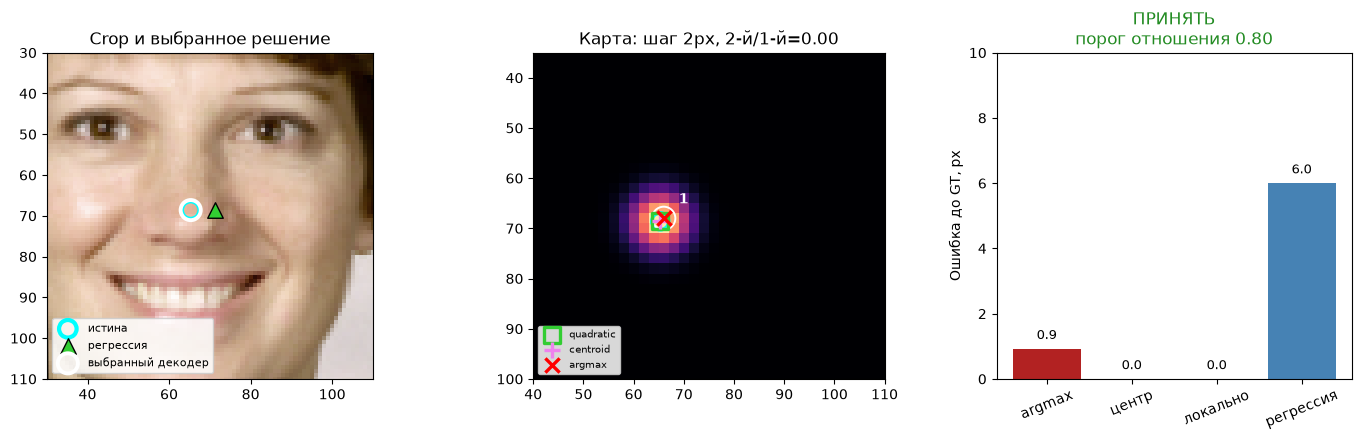

Пики (crop x,y; значение): [((np.int64(66), np.int64(68)), 0.974)]
Отношение второго пика к первому: 0.0 ; решение: ПРИНЯТЬ
Выбрана координата quadratic [65.3 68.6] ; ошибка: 0.0 px


In [12]:
HEAT_M = eye_transform(GT[:2], TARGET[:2])
HEAT_CROP = crop(PHOTO, HEAT_M)
HEAT_TRUE = move(GT, HEAT_M)[2]

def heat_local_peaks(heat):
    # Two separated 8-neighbour maxima; nearby tied grid cells count as one peak.
    h, w = heat.shape
    padded = np.pad(heat, 1, constant_values=-np.inf)
    is_peak = np.ones((h, w), dtype=bool)
    for dy in (-1, 0, 1):
        for dx in (-1, 0, 1):
            if dx or dy:
                is_peak &= heat >= padded[1+dy:1+dy+h, 1+dx:1+dx+w]
    candidates = np.argwhere(is_peak & (heat >= .05 * heat.max()))
    candidates = sorted(candidates,
                        key=lambda rc: (-heat[rc[0], rc[1]], int(rc[0]), int(rc[1])))
    peaks = []
    for row, col in candidates:
        row, col = int(row), int(col)
        if all(np.hypot(row-r, col-c) > 2 for r, c in peaks):
            peaks.append((row, col))
        if len(peaks) == 2:
            break
    return peaks

def heat_subpixel_log(heat, row, col, step):
    # Local 1-D quadratic interpolation of log-heat in x and y.
    base = np.array([col*step, row*step], dtype=float)
    if row == 0 or col == 0 or row == heat.shape[0]-1 or col == heat.shape[1]-1:
        return base
    logh = np.log(np.maximum(heat, 1e-12))
    def vertex(left, mid, right):
        den = left - 2*mid + right
        if den >= -1e-12:
            return 0.
        return float(np.clip(.5*(left-right)/den, -1., 1.))
    dx = vertex(logh[row,col-1], logh[row,col], logh[row,col+1])
    dy = vertex(logh[row-1,col], logh[row,col], logh[row+1,col])
    return base + step*np.array([dx, dy])

def heatmap_state(stride=2, sigma=4., decoy=0., decoy_dx=18,
                  reject_ratio=.80, direct_dx=6):
    step = int(stride)
    if step not in (1, 2, 4, 8) or sigma <= 0 or decoy < 0:
        raise ValueError("Проверьте шаг, ширину и высоту пика")
    if not 0 <= reject_ratio <= 1:
        raise ValueError("Порог отношения двух пиков должен быть в [0, 1]")
    xs = np.arange(0, 128, step, dtype=float)
    yy, xx = np.meshgrid(xs, xs, indexing="ij")
    x, y = HEAT_TRUE
    primary = np.exp(-((xx-x)**2 + (yy-y)**2)/(2*float(sigma)**2))
    secondary = np.exp(-((xx-(x+float(decoy_dx)))**2 + (yy-(y-12))**2)
                       /(2*float(sigma)**2))
    heat = primary + float(decoy)*secondary
    row, col = np.unravel_index(int(np.argmax(heat)), heat.shape)
    argmax = np.array([xs[col], xs[row]])
    centroid = np.array([(heat*xx).sum(), (heat*yy).sum()])/heat.sum()
    quadratic = heat_subpixel_log(heat, row, col, step)
    direct = HEAT_TRUE + [float(direct_dx), 0.]
    peaks = heat_local_peaks(heat)
    ratio = (float(heat[peaks[1]]/heat[peaks[0]]) if len(peaks) == 2 else 0.)
    estimates = {"argmax": argmax, "centroid": centroid,
                 "quadratic": quadratic, "direct": direct}
    errors = {name: float(np.linalg.norm(p-HEAT_TRUE))
              for name, p in estimates.items()}
    return {"heat": heat, "xs": xs, "truth": HEAT_TRUE, "step": step,
            "peaks": peaks, "peak_ratio": ratio,
            "reject": bool(len(peaks) == 2 and ratio >= reject_ratio),
            "estimates": estimates, "errors": errors}

def render_heatmap(stride=2, sigma=4., decoy=0., decoy_dx=18,
                   reject_ratio=.80, decoder="quadratic", direct_dx=6):
    state = heatmap_state(stride, sigma, decoy, decoy_dx,
                          reject_ratio, direct_dx)
    if decoder not in ("argmax", "centroid", "quadratic"):
        raise ValueError("Неизвестный декодер")
    estimates, errors = state["estimates"], state["errors"]
    selected = estimates[decoder]
    fig, ax = plt.subplots(1, 3, figsize=(14.2, 4.5),
                           gridspec_kw={"width_ratios": [1, 1, .84]})
    ax[0].imshow(HEAT_CROP)
    ax[0].scatter(*state["truth"], s=160, facecolors="none",
                  edgecolors="cyan", linewidths=3, label="истина")
    ax[0].scatter(*estimates["direct"], s=125, marker="^",
                  c="limegreen", edgecolors="black", label="регрессия")
    ax[0].scatter(*selected, s=210, facecolors="none", edgecolors="white",
                  linewidths=2.8, label="выбранный декодер")
    ax[0].set(xlim=(30, 110), ylim=(110, 30), title="Crop и выбранное решение")
    ax[0].legend(loc="lower left", fontsize=8, framealpha=.85)
    xs = state["xs"]
    ax[1].imshow(state["heat"], origin="upper",
                 extent=(-stride/2, xs[-1]+stride/2,
                         xs[-1]+stride/2, -stride/2),
                 cmap="magma", interpolation="nearest")
    ax[1].scatter(*state["truth"], s=150, facecolors="none",
                  edgecolors="cyan", linewidths=2.5)
    for rank, (row, col) in enumerate(state["peaks"], start=1):
        ax[1].scatter(col*stride, row*stride, s=280, facecolors="none",
                      edgecolors="white", linewidths=1.4, zorder=3)
        ax[1].annotate(str(rank), (col*stride+3, row*stride-3),
                       color="white", weight="bold", fontsize=10)
    ax[1].scatter(*estimates["quadratic"], s=135, marker="s",
                  facecolors="none", edgecolors="limegreen", linewidths=2.4,
                  label="quadratic", zorder=5)
    ax[1].scatter(*estimates["centroid"], s=120, marker="+", c="violet",
                  linewidths=2.4, label="centroid", zorder=6)
    ax[1].scatter(*estimates["argmax"], s=105, marker="x", c="red",
                  linewidths=2.4, label="argmax", zorder=7)
    ax[1].set(xlim=(40, 110), ylim=(100, 35),
              title=f"Карта: шаг {stride}px, 2-й/1-й={state['peak_ratio']:.2f}")
    ax[1].legend(loc="lower left", fontsize=7, framealpha=.85)
    labels = ["argmax", "центр", "локально", "регрессия"]
    keys = ["argmax", "centroid", "quadratic", "direct"]
    vals = [errors[key] for key in keys]
    bars = ax[2].bar(labels, vals,
                     color=["firebrick", "mediumpurple", "forestgreen", "steelblue"])
    for bar, value in zip(bars, vals):
        ax[2].text(bar.get_x()+bar.get_width()/2, bar.get_height()+.3,
                   f"{value:.1f}", ha="center", fontsize=9)
    ax[2].set(ylabel="Ошибка до GT, px", ylim=(0, max(vals)+4))
    decision = "ОТКАЗ: две близкие вершины" if state["reject"] else "ПРИНЯТЬ"
    ax[2].set_title(f"{decision}\nпорог отношения {reject_ratio:.2f}",
                    color="firebrick" if state["reject"] else "forestgreen")
    ax[2].tick_params(axis="x", labelrotation=22)
    finish(fig)
    print("Пики (crop x,y; значение):", [
        (tuple(np.round([col*stride, row*stride], 2)),
         round(float(state["heat"][row, col]), 3))
        for row, col in state["peaks"]])
    print("Отношение второго пика к первому:", round(state["peak_ratio"], 3),
          "; решение:", decision)
    print("Выбрана координата", decoder, np.round(selected, 2),
          "; ошибка:", round(errors[decoder], 2), "px")
    return state

_ = render_heatmap()

In [13]:
if widgets is not None:
    stand_controls("heatmap", render_heatmap,
        stride=widgets.SelectionSlider(options=[1, 2, 4, 8], value=2,
                                       description="Шаг сетки, px"),
        sigma=widgets.FloatSlider(value=4., min=2., max=9., step=1.,
                                  description="Ширина σ"),
        decoy=widgets.FloatSlider(value=0., min=0., max=1.6, step=.1,
                                  description="Ложный пик", readout_format=".1f"),
        decoy_dx=widgets.IntSlider(value=18, min=8, max=28, step=2,
                                   description="Расстояние x, px"),
        decoder=widgets.Dropdown(options=[("argmax", "argmax"),
                                           ("Центр массы", "centroid"),
                                           ("Локальная парабола", "quadratic")],
                                 value="quadratic", description="Декодер"),
        reject_ratio=widgets.FloatSlider(value=.80, min=.50, max=.99, step=.01,
                                         description="Отказ при 2-м пике",
                                         readout_format=".2f"),
        direct_dx=widgets.IntSlider(value=6, min=-20, max=20, step=1,
                                    description="Регрессия Δx"))

### Получите результат · 4 диагностических опыта

1. **Устраните ошибку дискретизации.** Поставьте ложный пик 0, шаг 8 px и σ=4. Сравните координату `argmax` с локальной параболой и истинной точкой. Затем уменьшайте шаг: найдите наибольший доступный шаг, при котором `argmax` ошибается меньше 1 px. Объясните, почему локальное уточнение при одном гауссовом пике точнее узла сетки.
2. **Найдите момент переключения области.** При шаге 2 px, σ=4, расстоянии 18 px повышайте ложный пик по 0.1. Запишите два соседних значения, между которыми `argmax` перешёл к ложной области. Сравните скачок ошибки `argmax` с изменением ошибки центра массы и локальной параболы. Почему локальное уточнение не спасает после выбора неверной вершины?
3. **Измените только решение об отказе.** Создайте две различимые вершины при ложном пике около 0.8 и запишите показанное отношение второго к первому. Не меняя карту и декодер, подберите два порога по разные стороны отношения, чтобы получить «принять» и «отказ». Убедитесь, что координата и ошибка остались прежними. Почему отношение нельзя называть вероятностью правильного ответа?
4. **Когда прямая координата лучше карты?** Оставьте регрессию Δx=+6 px. Подберите высоту и расстояние ложного пика, при которых её ошибка меньше ошибки каждого из трёх декодеров. Запишите координаты двух вершин и объясните, как конфликт пиков меняет `argmax`, центр массы и локальную параболу.

| Опыт | Прогноз до изменения | Настройки и две вершины | Ошибки / решение | Причина |
|---|---|---|---|---|
| Квантование |  |  |  |  |
| Смена области |  |  |  |  |
| Порог отказа |  |  |  |  |
| Регрессия против карты |  |  |  |  |

Порог отношения вершин в этом стенде выбран вручную. На реальной модели правило отказа выбирают по валидационной выборке; одной синтетической карты недостаточно для вывода о качестве архитектуры.

## Стенд 5. Три способа выравнивания и ловушка учебной ошибки

**Теория.** Цель преобразования — привести пять истинных точек к шаблону TARGET. Все три метода получают **оценённые**, а не истинные входные точки. По двум глазам определяется преобразование подобия: поворот, единый масштаб и перенос. Три точки (оба глаза и нос) определяют общую аффинную матрицу: при ошибке носа она может вводить сдвиг и неравномерный масштаб. Взвешенное подобие подбирает четыре параметра по пяти точкам; вес носа снижается, если он ненадёжен. Синий круг на crop — целевое положение, оранжевая точка — положение истинной точки после вычисленного преобразования.

**Два вида ошибки.** Для всех трёх методов показан один и тот же **диагностический остаток на первых трёх оценённых точках**; он не всегда совпадает с функцией потерь метода. Аффинное преобразование точно проходит через эти три оценки, но истинное лицо может быть выровнено плохо. Искажение = отношение большого и малого сингулярных чисел матрицы 2×2; у подобия оно равно 1. Отдельно показывается определитель: отрицательный знак означает отражение, которое отношение сингулярных чисел не выявляет. Если три входные оценки лежат на одной прямой, аффинная матрица не определяется.

**Цель.** Найдите сдвиг носа, при котором подгонка по трём оценённым точкам всё ещё даёт нулевой учебный остаток, но сильно портит реальные ориентиры.

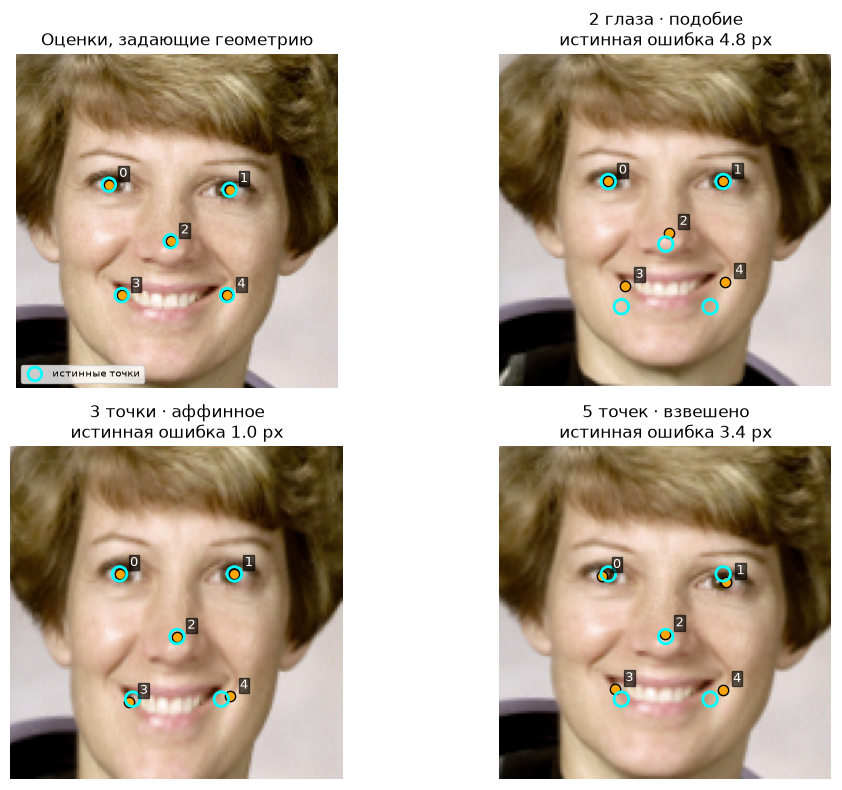

2 глаза · подобие: истинная ошибка 4.78 px; диагностика по первым 3 оценкам 1.53 px; искажение 1.00; det 0.875
3 точки · аффинное: истинная ошибка 0.98 px; диагностика по первым 3 оценкам 0.00 px; искажение 1.23; det 1.071
5 точек · взвешено: истинная ошибка 3.44 px; диагностика по первым 3 оценкам 2.20 px; искажение 1.00; det 1.016
Аффинная H (3×3):
 [[   0.937   -0.022 -144.108]
 [  -0.049    1.144  -56.761]
 [   0.       0.       1.   ]]


In [14]:
def demo_similarity(src, dst, weights):
    src=np.asarray(src,float); dst=np.asarray(dst,float); weights=np.asarray(weights,float)
    if src.shape!=(5,2) or dst.shape!=(5,2) or weights.shape!=(5,):
        raise ValueError("Ожидаются пять точек и пять весов")
    if np.any(weights<0) or not np.all(np.isfinite(weights)):
        raise ValueError("Веса должны быть неотрицательными и конечными")
    design=np.zeros((10,4))
    design[0::2,0]=src[:,0];design[0::2,1]=-src[:,1];design[0::2,2]=1.
    design[1::2,0]=src[:,1];design[1::2,1]=src[:,0];design[1::2,3]=1.
    sw=np.repeat(np.sqrt(weights),2)
    if np.linalg.matrix_rank(design*sw[:,None])<4:
        raise ValueError("Недостаточно независимых ориентиров для подобия")
    a,b,tx,ty=np.linalg.lstsq(design*sw[:,None],
                              dst.reshape(-1)*sw,rcond=None)[0]
    return np.array([[a,-b,tx],[b,a,ty]],float)

def three_point_affine(src3,dst3):
    src3=np.asarray(src3,float);dst3=np.asarray(dst3,float)
    if src3.shape!=(3,2) or dst3.shape!=(3,2):
        raise ValueError("Нужны три пары точек")
    if abs(np.linalg.det(np.column_stack([src3,np.ones(3)])))<5.:
        raise ValueError("Треугольник оценённых точек вырожден: 2S < 5 px²")
    return cv2.getAffineTransform(src3.astype(np.float32),dst3.astype(np.float32)).astype(float)

def advanced_alignment_state(eye_dx=0.,eye_dy=0.,nose_dx=0.,nose_dy=0.,
                             nose_weight=.1,mouth_weight=.5):
    pred=GT.copy()
    pred[1]+=[float(eye_dx),float(eye_dy)]
    pred[2]+=[float(nose_dx),float(nose_dy)]
    eye_key="2 глаза · подобие"
    affine_key="3 точки · аффинное"
    weighted_key="5 точек · взвешено"
    methods={eye_key:eye_transform(pred[:2],TARGET[:2])}
    try:
        methods[affine_key]=three_point_affine(pred[:3],TARGET[:3])
        affine_problem=None
    except ValueError as exc:
        methods[affine_key]=None
        affine_problem=str(exc)
    methods[weighted_key]=demo_similarity(
        pred,TARGET,np.array([1.,1.,nose_weight,mouth_weight,mouth_weight]))
    result={}
    for name,M in methods.items():
        if M is None:
            result[name]={"valid":False,"reason":affine_problem}
            continue
        true_after=move(GT,M)
        predicted_after=move(pred,M)
        true_errors=np.linalg.norm(true_after-TARGET,axis=1)
        fit_error=float(np.mean(np.linalg.norm(predicted_after[:3]-TARGET[:3],axis=1)))
        singular=np.linalg.svd(M[:,:2],compute_uv=False)
        determinant=float(np.linalg.det(M[:,:2]))
        result[name]={"valid":True,"M":M,"H":np.vstack([M,[0,0,1]]),
                      "true_after":true_after,"true_errors":true_errors,
                      "mean_true_error":float(true_errors.mean()),
                      "fit_error_first3":fit_error,
                      "anisotropy":float(singular[0]/singular[-1]),
                      "determinant":determinant,"reflection":bool(determinant<0)}
    return {"pred":pred,"methods":result}

def render_advanced_alignment(eye_dx=0.,eye_dy=0.,nose_dx=0.,nose_dy=0.,
                              nose_weight=.1,mouth_weight=.5):
    s=advanced_alignment_state(eye_dx,eye_dy,nose_dx,nose_dy,
                               nose_weight,mouth_weight)
    fig,ax=plt.subplots(2,2,figsize=(11,8))
    show_points(ax[0,0],PHOTO,s["pred"],"Оценки, задающие геометрию")
    ax[0,0].scatter(GT[:,0],GT[:,1],s=95,facecolors="none",
                    edgecolors="cyan",linewidths=2,label="истинные точки")
    ax[0,0].set(xlim=(165,290),ylim=(180,50))
    ax[0,0].legend(loc="lower left",fontsize=7)
    for axis,(name,item) in zip(ax.flat[1:],s["methods"].items()):
        if not item["valid"]:
            axis.set(xlim=(0,1),ylim=(0,1),title=name+" · не определено")
            axis.text(.5,.55,item["reason"],ha="center",va="center",
                      transform=axis.transAxes,fontsize=10)
            axis.axis("off")
            continue
        out=crop(PHOTO,item["M"])
        flag=" · ОТРАЖЕНИЕ" if item["reflection"] else ""
        show_points(axis,out,item["true_after"],
                    f"{name}{flag}\nистинная ошибка {item['mean_true_error']:.1f} px")
        for label in axis.texts:
            label.set_clip_on(True)
        axis.scatter(TARGET[:,0],TARGET[:,1],s=110,facecolors="none",
                     edgecolors="cyan",linewidths=2)
        axis.set(xlim=(0,128),ylim=(128,0))
    finish(fig)
    for name,item in s["methods"].items():
        if not item["valid"]:
            print(name+":",item["reason"])
            continue
        print(f"{name}: истинная ошибка {item['mean_true_error']:.2f} px; "
              f"диагностика по первым 3 оценкам {item['fit_error_first3']:.2f} px; "
              f"искажение {item['anisotropy']:.2f}; det {item['determinant']:.3f}"
              + (" · ОТРАЖЕНИЕ" if item["reflection"] else ""))
    affine=s["methods"]["3 точки · аффинное"]
    if affine["valid"]:
        print("Аффинная H (3×3):\n",np.round(affine["H"],3))
    return s
_ = render_advanced_alignment()

In [15]:
if widgets is not None:
    stand_controls("alignment_advanced",render_advanced_alignment,
        eye_dx=widgets.IntSlider(value=0,min=-15,max=15,step=1,
                                 description="Правый глаз Δx"),
        eye_dy=widgets.IntSlider(value=0,min=-15,max=15,step=1,
                                 description="Правый глаз Δy"),
        nose_dx=widgets.IntSlider(value=0,min=-30,max=30,step=1,
                                  description="Нос Δx"),
        nose_dy=widgets.IntSlider(value=0,min=-30,max=30,step=1,
                                  description="Нос Δy"),
        nose_weight=widgets.SelectionSlider(options=[0.,.05,.1,.25,.5,1.],
                                            value=.1,description="Вес носа"),
        mouth_weight=widgets.SelectionSlider(options=[0.,.25,.5,1.],
                                             value=.5,description="Вес рта"))

**Задания с поиском решения.**

1. При нулевых сдвигах измерьте ошибки трёх методов. Объясните, почему даже при верных точках шаблон может давать ненулевую среднюю ошибку.
2. Поставьте нос (+22, −12), глаз оставьте без ошибки. Найдите метод с нулевым остатком на первых трёх **оценённых** точках и максимальной ошибкой **истинных** точек. Запишите его аффинную H и показатель искажения.
3. Сохранив смещение носа, опустите его вес от 1 к 0. Найдите наибольший вес, при котором ошибка взвешенного метода ещё меньше ошибки по двум глазам. Укажите результат и вес рта.
4. Обнулите ошибку носа, измените только правый глаз на Δy=+10. Какие преобразования меняются? Сравните угол и визуальную геометрию, а не только итоговое число.
5. Верните глаз в 0 и найдите ненулевой сдвиг носа, при котором аффинный метод становится хуже двухглазого хотя диагностический остаток остаётся около нуля. Что этот случай говорит о риске оценки по тем же ориентирам?
6. Установите правый глаз Δy=−2 и нос Δy=−22: почему аффинный результат не определён? Затем измените нос Δy до −30 и найдите предупреждение об отражении; объясните, почему искажение по сингулярным числам его не показывает.

| Настройка | Метод | Диагностика по 3 оценкам, px | Истинная ошибка, px | Искажение / det |
|---|---|---:|---:|---:|
| Все сдвиги 0 |  |  |  |  |
| Нос (+22, −12) |  |  |  |  |
| Сниженный вес носа |  |  |  |  |
| Ошибка глаза |  |  |  |  |
| Коллинеарность / отражение |  |  |  |  |

Все входные ошибки заданы вручную на одном снимке; это геометрический опыт, а не сравнение качества трёх обученных моделей.

## Стенд 6. Выбор веса на серии случаев и отложенный test

**Механизм.** Один удачный crop не показывает устойчивость метода. Ниже 12 **детерминированных учебных случаев** на том же снимке: у части точны все ориентиры, у части нос, глаз или угол рта ошибаются. Шесть случаев образуют val, ещё шесть — отложенный test. Чистый базовый случай повторён для контроля; остальные сдвиги различаются. Это наборы ошибок на одном лице, а не независимая выборка людей. В каждом случае взвешенное подобие оценивается по ошибочным точкам; качество проверяется по пяти исходным ручным точкам после переноса к шаблону.

Меняйте вес носа, вес рта, целевой показатель и порог неуспеха. Порог неуспеха применяется ретроспективно к истинной ошибке после проверки разметки; в отличие от стенда 4 это не правило отказа во время вывода. Средняя ошибка по val и 90-й перцентиль отвечают на разные вопросы: первая описывает типичный итог, второй чувствительнее к плохим случаям. Кнопка фиксирует настройки и раскрывает результаты test; после этого менять веса в текущем прогоне нельзя. Определения test-сценариев видны в коде для воспроизводимости: кнопка задаёт порядок анализа, а не скрывает данные как защищённый серверный оценщик. Сначала запишите прогноз test в таблицу, затем нажмите кнопку. Виджет можно перезапустить выполнением этой ячейки заново, но уже увиденный test нельзя считать новой независимой проверкой.

**Цель.** Найдите вес носа, минимизирующий среднюю ошибку val, и отдельно вес для 90-го перцентиля. Сравните эти решения и один раз оцените заранее выбранное на test.

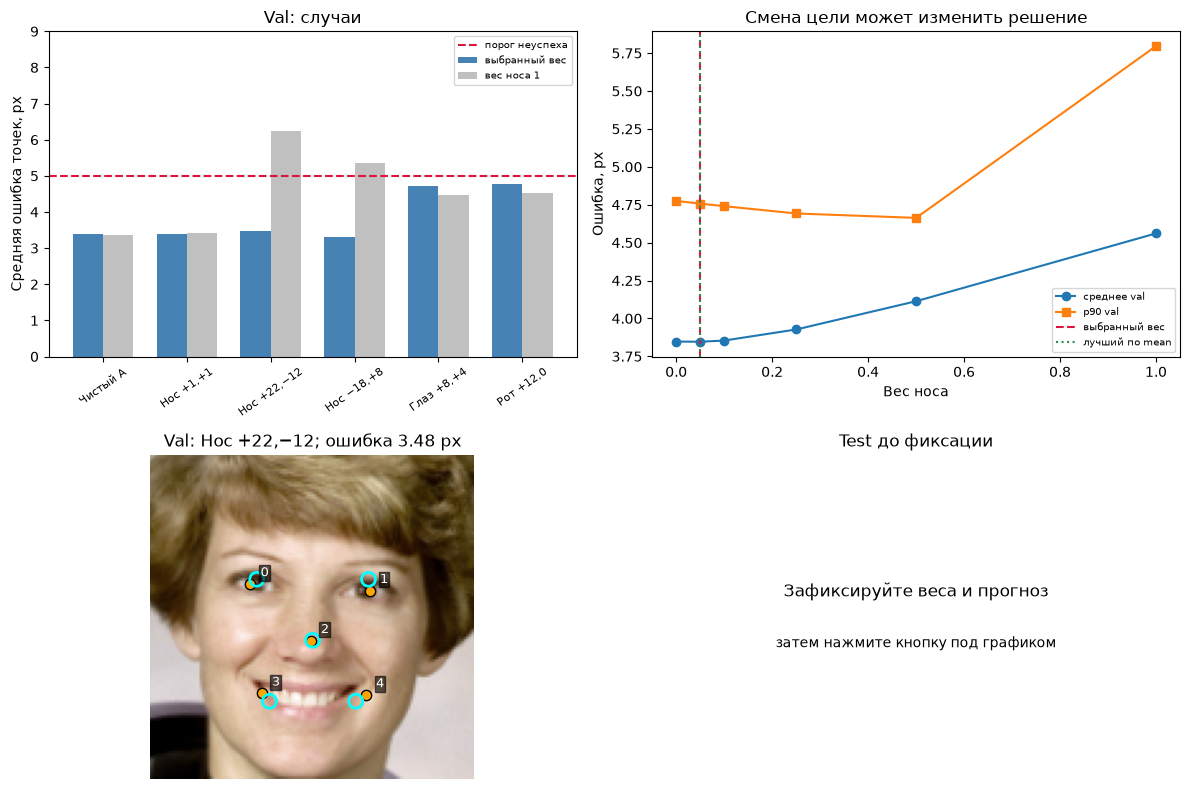

Val: среднее 3.85 px; p90 4.76 px; неуспехов 0/6 при пороге 5 px
Минимум mean по сетке весов: w=0.05, значение 3.85 px


In [16]:
BATCH_WEIGHTS=np.array([0.,.05,.1,.25,.5,1.])
def _offset(nose=(0,0),eye=(0,0),mouth=(0,0)):
    x=np.zeros((5,2),float)
    x[2]=nose;x[1]=eye;x[3]=mouth
    return x
BATCH_CASES={
    "val":[
        ("Чистый A",_offset()),
        ("Нос +1,+1",_offset(nose=(1,1))),
        ("Нос +22,−12",_offset(nose=(22,-12))),
        ("Нос −18,+8",_offset(nose=(-18,8))),
        ("Глаз +8,+4",_offset(eye=(8,4))),
        ("Рот +12,0",_offset(mouth=(12,0)))],
    "test":[
        ("Чистый B",_offset()),
        ("Нос −24,+15",_offset(nose=(-24,15))),
        ("Нос +28,+12",_offset(nose=(28,12))),
        ("Глаз +7,−8",_offset(eye=(7,-8))),
        ("Рот −12,+9",_offset(mouth=(-12,9))),
        ("Нос −2,+1",_offset(nose=(-2,1)))]}
def _batch_case_error(offset,nose_weight,mouth_weight):
    estimated=GT+offset
    M=demo_similarity(estimated,TARGET,
                      [1.,1.,float(nose_weight),float(mouth_weight),float(mouth_weight)])
    err=float(np.linalg.norm(move(GT,M)-TARGET,axis=1).mean())
    return err,M
def _batch_errors(split,nose_weight,mouth_weight):
    return np.array([_batch_case_error(offset,nose_weight,mouth_weight)[0]
                     for _,offset in BATCH_CASES[split]],float)
def _batch_summary(errors,fail_limit):
    return {"mean":float(np.mean(errors)),
            "p90":float(np.quantile(errors,.9)),
            "failures":int(np.sum(errors>fail_limit))}
def batch_state(nose_weight=.05,mouth_weight=1.,criterion="mean",
                fail_limit=5.,selected_case=2,reveal_test=False):
    w=float(nose_weight);wm=float(mouth_weight);cutoff=float(fail_limit)
    if not 0<=w<=1 or not 0<=wm<=1 or cutoff<=0:
        raise ValueError("Недопустимые веса или порог")
    if criterion not in ("mean","p90"):
        raise ValueError("Неизвестная цель")
    vals=np.array([_batch_errors("val",ww,wm) for ww in BATCH_WEIGHTS])
    curve_mean=vals.mean(axis=1)
    curve_p90=np.quantile(vals,.9,axis=1)
    target_curve=curve_mean if criterion=="mean" else curve_p90
    best_index=int(np.argmin(target_curve))
    val=_batch_errors("val",w,wm)
    test=_batch_errors("test",w,wm) if reveal_test else None
    return {"weight":w,"mouth_weight":wm,"criterion":criterion,
            "fail_limit":cutoff,"selected_case":int(selected_case),
            "val":val,"test":test,
            "val_summary":_batch_summary(val,cutoff),
            "test_summary":_batch_summary(test,cutoff) if test is not None else None,
            "curve_mean":curve_mean,"curve_p90":curve_p90,
            "best_weight":float(BATCH_WEIGHTS[best_index]),
            "best_score":float(target_curve[best_index])}
def render_batch(nose_weight=.05,mouth_weight=1.,criterion="mean",
                 fail_limit=5.,selected_case=2,reveal_test=False):
    s=batch_state(nose_weight,mouth_weight,criterion,fail_limit,
                  selected_case,reveal_test)
    names=[name for name,_ in BATCH_CASES["val"]]
    idx=s["selected_case"]
    if not 0<=idx<len(names):
        raise ValueError("Выбранного val-случая нет")
    offset=BATCH_CASES["val"][idx][1]
    _,M=_batch_case_error(offset,nose_weight,mouth_weight)
    fig,ax=plt.subplots(2,2,figsize=(12,8))
    xs=np.arange(len(names))
    ax[0,0].bar(xs-.18,s["val"],.36,color="steelblue",label="выбранный вес")
    ax[0,0].bar(xs+.18,_batch_errors("val",1.,mouth_weight),.36,
                color="silver",label="вес носа 1")
    ax[0,0].axhline(fail_limit,color="crimson",linestyle="--",
                    label="порог неуспеха")
    ax[0,0].set(xticks=xs,xticklabels=names,ylim=(0,max(9,float(np.max(s["val"])+2))),
                ylabel="Средняя ошибка точек, px",title="Val: случаи")
    ax[0,0].tick_params(axis="x",labelrotation=35,labelsize=8)
    ax[0,0].legend(fontsize=7)
    ax[0,1].plot(BATCH_WEIGHTS,s["curve_mean"],"o-",label="среднее val")
    ax[0,1].plot(BATCH_WEIGHTS,s["curve_p90"],"s-",label="p90 val")
    ax[0,1].axvline(nose_weight,color="crimson",linestyle="--",label="выбранный вес")
    ax[0,1].axvline(s["best_weight"],color="seagreen",linestyle=":",
                    label=f"лучший по {criterion}")
    ax[0,1].set(xlabel="Вес носа",ylabel="Ошибка, px",
                title="Смена цели может изменить решение")
    ax[0,1].legend(fontsize=7)
    out=crop(PHOTO,M)
    show_points(ax[1,0],out,move(GT,M),
                f"Val: {names[idx]}; ошибка {s['val'][idx]:.2f} px")
    ax[1,0].scatter(TARGET[:,0],TARGET[:,1],s=100,facecolors="none",
                    edgecolors="cyan",linewidths=2)
    ax[1,0].set(xlim=(0,128),ylim=(128,0))
    if s["test"] is None:
        ax[1,1].set(xlim=(0,1),ylim=(0,1),title="Test до фиксации")
        ax[1,1].text(.5,.58,"Зафиксируйте веса и прогноз",ha="center",va="center",
                     fontsize=12)
        ax[1,1].text(.5,.42,"затем нажмите кнопку под графиком",ha="center",
                     va="center",fontsize=10)
        ax[1,1].axis("off")
    else:
        test_names=[name for name,_ in BATCH_CASES["test"]]
        ax[1,1].bar(np.arange(len(test_names)),s["test"],color="darkorange")
        ax[1,1].axhline(fail_limit,color="crimson",linestyle="--")
        ax[1,1].set(xticks=np.arange(len(test_names)),xticklabels=test_names,
                    ylabel="Ошибка, px",title="Test после фиксации")
        ax[1,1].tick_params(axis="x",labelrotation=35,labelsize=8)
    finish(fig)
    v=s["val_summary"]
    print(f"Val: среднее {v['mean']:.2f} px; p90 {v['p90']:.2f} px; "
          f"неуспехов {v['failures']}/6 при пороге {fail_limit:g} px")
    print(f"Минимум {criterion} по сетке весов: w={s['best_weight']:g}, "
          f"значение {s['best_score']:.2f} px")
    if s["test_summary"] is not None:
        t=s["test_summary"]
        print(f"ЗАФИКСИРОВАННЫЙ test: среднее {t['mean']:.2f} px; "
              f"p90 {t['p90']:.2f} px; неуспехов {t['failures']}/6")
    return s
_ = render_batch()

In [ ]:
if widgets is not None:
    batch_weight=widgets.SelectionSlider(options=list(BATCH_WEIGHTS),value=.05,
                                         description="Вес носа")
    batch_mouth=widgets.SelectionSlider(options=[0.,.25,.5,1.],value=1.,
                                        description="Вес рта")
    batch_goal=widgets.Dropdown(options=[("Среднее","mean"),("90-й перцентиль","p90")],
                                value="mean",description="Цель val")
    batch_limit=widgets.FloatSlider(value=5.,min=3.,max=10.,step=.5,
                                    description="Порог неуспеха")
    batch_case=widgets.Dropdown(options=[(n,i) for i,(n,_) in
                                         enumerate(BATCH_CASES["val"])],
                                value=2,description="Случай val")
    batch_button=widgets.Button(description="Зафиксировать и открыть test",
                                 button_style="warning",
                                 icon="lock")
    batch_output=widgets.Output()
    BATCH_LOCK={"locked":False,"snapshot":None}
    for control in (batch_weight,batch_mouth,batch_goal,batch_limit,batch_case):
        control.style={"description_width":"155px"}
        control.layout=widgets.Layout(width="470px")
    def _batch_redraw(change=None):
        with batch_output:
            batch_output.clear_output(wait=True)
            params=BATCH_LOCK["snapshot"] if BATCH_LOCK["locked"] else {
                "nose_weight":batch_weight.value,
                "mouth_weight":batch_mouth.value,
                "criterion":batch_goal.value,
                "fail_limit":batch_limit.value}
            render_batch(**params,selected_case=batch_case.value,
                         reveal_test=BATCH_LOCK["locked"])
    def _batch_lock(button):
        if BATCH_LOCK["locked"]:
            return
        BATCH_LOCK["snapshot"]={
            "nose_weight":batch_weight.value,
            "mouth_weight":batch_mouth.value,
            "criterion":batch_goal.value,
            "fail_limit":batch_limit.value}
        BATCH_LOCK["locked"]=True
        for control in (batch_weight,batch_mouth,batch_goal,batch_limit):
            control.disabled=True
        batch_button.disabled=True
        batch_button.description="Решение зафиксировано"
        _batch_redraw()
    for control in (batch_weight,batch_mouth,batch_goal,batch_limit,batch_case):
        control.observe(_batch_redraw,names="value")
    batch_button.on_click(_batch_lock)
    display(widgets.VBox([batch_weight,batch_mouth,batch_goal,batch_limit,
                          batch_case,batch_button,batch_output]))
    CONTROL_PANELS["batch"]={
        "nose_weight":batch_weight,"mouth_weight":batch_mouth,
        "criterion":batch_goal,"fail_limit":batch_limit,
        "selected_case":batch_case,"button":batch_button}
    _batch_redraw()

**Задания и запись результата.**

1. На val найдите лучшие веса носа по двум целям — среднему и p90 — при весе рта 1. Запишите обе ошибки, распределение по шести случаям и причину разницы. Отдельно проверьте, как число случаев с ошибкой выше порога меняется при пороге 4 и 5 px без изменения предсказаний.
2. Измените вес рта на 0.25. Сравните кривую по весу носа и один crop с тем же типом ошибки. Объясните, какая группа ориентиров теперь сильнее задаёт преобразование.
3. Верните вес рта 1, выберите одну цель и вес **только по val**. Запишите прогноз о среднем, p90 и числе неуспехов на test. Лишь затем нажмите кнопку фиксации.
4. Сравните test с прогнозом и val. Отметьте test-случаи с ошибкой выше выбранного порога или p90 val; объясните, почему один снимок с 12 сдвигами не даёт оценки обобщения на других людей.

| Выбор, сделанный до test | Среднее val | p90 val | Прогноз test | Реальный test |
|---|---:|---:|---|---|
| Вес по среднему |  |  |  |  |
| Вес по p90 |  |  |  |  |
| Зафиксированное решение |  |  |  |  |

Стенд не даёт опубликованных benchmark-показателей. Для вывода о точности и скорости реальной сети нужны независимые изображения, разметка, единый протокол и измерение времени на известном устройстве.

## Необязательный локальный снимок

Можно исследовать собственное изображение только локально: укажите путь и вручную задайте пять точек в том же порядке. Ячейка выключена по умолчанию. Она не оценивает личность и не сохраняет снимок в репозитории. Если запускали её на личном фото, перед сдачей удалите вывод ячейки.

In [ ]:
RUN_CUSTOM=False
CUSTOM_PATH=None
CUSTOM_POINTS=None
if RUN_CUSTOM:
    if not CUSTOM_PATH or CUSTOM_POINTS is None:
        raise ValueError("Укажите путь и пять точек")
    raw = Path(CUSTOM_PATH).read_bytes()
    own = cv2.imdecode(np.frombuffer(raw, np.uint8), cv2.IMREAD_COLOR)
    if own is None:
        raise ValueError("Изображение не прочитано")
    own = cv2.cvtColor(own, cv2.COLOR_BGR2RGB)
    own_points = np.asarray(CUSTOM_POINTS, float)
    if own_points.shape != (5, 2):
        raise ValueError("Нужны пять точек в пикселях исходного снимка")
    own_M = eye_transform(own_points[:2], TARGET[:2])
    fig, ax = plt.subplots(1, 2, figsize=(8, 4))
    show_points(ax[0], own, own_points, "Локальный снимок")
    show_points(ax[1], crop(own, own_M), move(own_points, own_M), "Выровнено")
    finish(fig)
else:
    print("Необязательный снимок выключен")

## Итог демо

Сохраните таблицы шести стендов и зафиксированное решение val/test. В выводе свяжите весь конвейер: снимок → реальная рамка и точки → crop → протокол разметки и метрики → координата из карты → преобразование → проверка на нескольких случаях. Назовите два различия между учебными фиксированными примерами и оценкой обученной модели на независимой выборке. Основной ноутбук превращает наблюдения в собственную реализацию с явными проверками.